## Configurations for Colab

In [6]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !apt install python-opengl
    !apt install ffmpeg
    !apt install xvfb
    !pip install PyVirtualDisplay==3.0
    !pip install gymnasium==0.28.1
    from pyvirtualdisplay import Display
    
    # Start virtual display
    dis = Display(visible=0, size=(400, 400))
    dis.start()

# 03. Prioritized Experience Replay (PER)

[T. Schaul et al., "Prioritized Experience Replay." arXiv preprint arXiv:1511.05952, 2015.](https://arxiv.org/pdf/1511.05952.pdf)

Using a replay memory leads to design choices at two levels: which experiences to store, and which experiences to replay (and how to do so). This paper addresses only the latter: making the most effective use of the replay memory for learning, assuming that its contents are outside of our control.

The central component of prioritized replay is the criterion by which the importance of each transition is measured. A reasonable approach is to use the magnitude of a transition’s TD error $\delta$, which indicates how ‘surprising’
or unexpected the transition is. This algorithm stores the last encountered TD error along with each transition in the replay memory. The transition with the largest absolute TD error is replayed from the memory. A Q-learning update
is applied to this transition, which updates the weights in proportion to the TD error. One thing to note that new transitions arrive without a known TD-error, so it puts them at maximal priority in order to guarantee that all experience is seen at least once. (see *store* method)

We might use 2 ideas to deal with TD-error: 1. greedy TD-error prioritization, 2. stochastic prioritization. However, greedy TD-error prioritization has a severe drawback. Greedy prioritization focuses on a small subset of the experience: errors shrink slowly, especially when using function approximation, meaning that the initially high error transitions get replayed frequently. This lack of diversity that makes the system prone to over-fitting. To overcome this issue, we will use a stochastic sampling method that interpolates between pure greedy prioritization and uniform random sampling.

$$
P(i) = \frac{p_i^{\alpha}}{\sum_k p_k^{\alpha}}
$$

where $p_i > 0$ is the priority of transition $i$. The exponent $\alpha$ determines how much prioritization is used, with $\alpha = 0$ corresponding to the uniform case. In practice, we use additional term $\epsilon$ in order to guarantee all transactions can be possibly sampled: $p_i = |\delta_i| + \epsilon$, where $\epsilon$ is a small positive constant.

One more. Let's recall one of the main ideas of DQN. To remove correlation of observations, it uses uniformly random sampling from the replay buffer. Prioritized replay introduces bias because it doesn't sample experiences uniformly at random due to the sampling proportion correspoding to TD-error. We can correct this bias by using importance-sampling (IS) weights

$$
w_i = \big( \frac{1}{N} \cdot \frac{1}{P(i)} \big)^\beta
$$

that fully compensates for the non-uniform probabilities $P(i)$ if $\beta = 1$. These weights can be folded into the Q-learning update by using $w_i\delta_i$ instead of $\delta_i$. In typical reinforcement learning scenarios, the unbiased nature of the updates is most important near convergence at the end of training, We therefore exploit the flexibility of annealing the amount of importance-sampling correction over time, by defining a schedule on the exponent $\beta$ that reaches 1 only at the end of learning. 

In [7]:
import os
import random
from typing import Dict, List, Tuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import clear_output

if IN_COLAB and not os.path.exists("segment_tree.py"):
    # download segment tree module
    !wget https://raw.githubusercontent.com/curt-park/rainbow-is-all-you-need/master/segment_tree.py
        
from segment_tree import MinSegmentTree, SumSegmentTree

## Replay buffer

Please see *01.dqn.ipynb* for detailed description.

In [8]:
class ReplayBuffer:
    """A simple numpy replay buffer."""

    def __init__(self, obs_dim: int, size: int, batch_size: int = 32):
        self.obs_buf = np.zeros([size, obs_dim], dtype=np.float32)
        self.next_obs_buf = np.zeros([size, obs_dim], dtype=np.float32)
        self.acts_buf = np.zeros([size], dtype=np.float32)
        self.rews_buf = np.zeros([size], dtype=np.float32)
        self.done_buf = np.zeros(size, dtype=np.float32)
        self.max_size, self.batch_size = size, batch_size
        self.ptr, self.size, = 0, 0

    def store(
        self,
        obs: np.ndarray,
        act: np.ndarray, 
        rew: float, 
        next_obs: np.ndarray, 
        done: bool,
    ):
        self.obs_buf[self.ptr] = obs
        self.next_obs_buf[self.ptr] = next_obs
        self.acts_buf[self.ptr] = act
        self.rews_buf[self.ptr] = rew
        self.done_buf[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample_batch(self) -> Dict[str, np.ndarray]:
        idxs = np.random.choice(self.size, size=self.batch_size, replace=False)
        return dict(obs=self.obs_buf[idxs],
                    next_obs=self.next_obs_buf[idxs],
                    acts=self.acts_buf[idxs],
                    rews=self.rews_buf[idxs],
                    done=self.done_buf[idxs])

    def __len__(self) -> int:
        return self.size

## Prioritized replay Buffer

The key concept of PER's implementation is *Segment Tree*. It efficiently stores and samples transitions while managing the priorities of them. We recommend you understand how it works before you move on. Here are references for you:

- In Korean: https://mrsyee.github.io/rl/2019/01/25/PER-sumtree/
- In English: https://www.geeksforgeeks.org/segment-tree-set-1-sum-of-given-range/

In [9]:
class PrioritizedReplayBuffer(ReplayBuffer):
    """Prioritized Replay Buffer.
    
    A buffer that implements prioritized experience replay, where transitions with higher 
    priorities are sampled more frequently. This class extends the base ReplayBuffer class.
    
    Attributes:
        max_priority (float): The maximum priority currently assigned to a transition.
        tree_ptr (int): Pointer to the current position in the segment tree for storing priorities.
        alpha (float): Controls the level of prioritization. If alpha = 0, all transitions are sampled uniformly.
        sum_tree (SumSegmentTree): Segment tree to store and compute sum of priorities.
        min_tree (MinSegmentTree): Segment tree to store and compute minimum priority, used for importance sampling.
    """
    
    def __init__(self, obs_dim: int, size: int, batch_size: int = 32, alpha: float = 0.6):
        """Initialize the prioritized replay buffer.
        
        Args:
            obs_dim (int): Dimension of the observation space.
            size (int): Maximum number of transitions the buffer can hold.
            batch_size (int): Number of samples to retrieve in each batch. Default is 32.
            alpha (float): Prioritization parameter; controls the level of prioritization. Default is 0.6.
        """
        assert alpha >= 0  # Ensure alpha is non-negative.
        
        # Initialize the base ReplayBuffer.
        super(PrioritizedReplayBuffer, self).__init__(obs_dim, size, batch_size)
        
        self.max_priority = 1.0  # Initial maximum priority.
        self.tree_ptr = 0  # Start at the first index in the priority tree.
        self.alpha = alpha  # Set prioritization parameter.
        
        # Ensure the capacity of the segment trees is a power of 2.
        tree_capacity = 1
        while tree_capacity < self.max_size:
            tree_capacity *= 2  # Double the capacity until it exceeds max_size.

        # Initialize the segment trees for sum and min priorities.
        self.sum_tree = SumSegmentTree(tree_capacity)
        self.min_tree = MinSegmentTree(tree_capacity)
        
    def store(self, obs: np.ndarray, act: int, rew: float, next_obs: np.ndarray, done: bool):
        """Store a transition in the replay buffer with the highest priority.
        
        Args:
            obs (np.ndarray): Current observation.
            act (int): Action taken.
            rew (float): Reward received.
            next_obs (np.ndarray): Next observation.
            done (bool): Whether the episode is done.
        """
        # Store the transition in the base replay buffer.
        super().store(obs, act, rew, next_obs, done)
        
        # Assign the maximum priority to the new transition.
        priority = self.max_priority ** self.alpha
        self.sum_tree[self.tree_ptr] = priority  # Update sum tree.
        self.min_tree[self.tree_ptr] = priority  # Update min tree.
        
        # Move the tree pointer to the next position, cycling back if needed.
        self.tree_ptr = (self.tree_ptr + 1) % self.max_size

    def sample_batch(self, beta: float = 0.4) -> Dict[str, np.ndarray]:
        """Sample a batch of transitions with importance sampling weights.
        
        Args:
            beta (float): Parameter to control importance sampling adjustment. Default is 0.4.
        
        Returns:
            Dict[str, np.ndarray]: A dictionary containing the sampled transitions and weights.
        """
        assert len(self) >= self.batch_size  # Ensure the buffer has enough samples.
        assert beta > 0  # Beta must be positive.
        
        # Sample indices proportionally to their priorities.
        indices = self._sample_proportional()
        
        # Retrieve the transitions corresponding to the sampled indices.
        obs = self.obs_buf[indices]
        next_obs = self.next_obs_buf[indices]
        acts = self.acts_buf[indices]
        rews = self.rews_buf[indices]
        done = self.done_buf[indices]
        
        # Calculate importance sampling weights for each sampled transition.
        weights = np.array([self._calculate_weight(i, beta) for i in indices])
        
        # Return the batch of transitions and associated weights.
        return dict(
            obs=obs,
            next_obs=next_obs,
            acts=acts,
            rews=rews,
            done=done,
            weights=weights,
            indices=indices,
        )
        
    def update_priorities(self, indices: List[int], priorities: np.ndarray):
        """Update the priorities of sampled transitions.
        
        Args:
            indices (List[int]): Indices of the transitions to update.
            priorities (np.ndarray): New priorities for the transitions.
        """
        assert len(indices) == len(priorities)  # Ensure indices and priorities match in length.

        for idx, priority in zip(indices, priorities):
            assert priority > 0  # Priorities must be positive.
            assert 0 <= idx < len(self)  # Indices must be valid.

            # Update the priorities in both trees.
            self.sum_tree[idx] = priority ** self.alpha
            self.min_tree[idx] = priority ** self.alpha

            # Update the maximum priority if needed.
            self.max_priority = max(self.max_priority, priority)
            
    def _sample_proportional(self) -> List[int]:
        """Sample indices based on priority proportions.
        
        Returns:
            List[int]: List of sampled indices.
        """
        indices = []
        # Total sum of priorities.
        p_total = self.sum_tree.sum(0, len(self) - 1)
        # Divide the priority range into equal segments.
        segment = p_total / self.batch_size
        
        for i in range(self.batch_size):
            # Determine the range of the current segment.
            a = segment * i
            b = segment * (i + 1)
            # Sample a value uniformly from the segment range.
            upperbound = random.uniform(a, b)
            # Retrieve the index corresponding to the sampled value.
            idx = self.sum_tree.retrieve(upperbound)
            indices.append(idx)
            
        return indices
    
    def _calculate_weight(self, idx: int, beta: float):
        """Calculate the importance sampling weight for a transition.
        
        Args:
            idx (int): Index of the transition.
            beta (float): Importance sampling parameter.
        
        Returns:
            float: Importance sampling weight.
        """
        # Minimum probability of sampling any transition.
        p_min = self.min_tree.min() / self.sum_tree.sum()
        # Maximum possible weight for normalization.
        max_weight = (p_min * len(self)) ** (-beta)
        
        # Probability of sampling the current transition.
        p_sample = self.sum_tree[idx] / self.sum_tree.sum()
        # Calculate the importance sampling weight.
        weight = (p_sample * len(self)) ** (-beta)
        # Normalize the weight by dividing by the maximum weight.
        weight = weight / max_weight
        
        return weight

## Network

We are going to use a simple network architecture with three fully connected layers and two non-linearity functions (ReLU).

In [10]:
class Network(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        """Initialization."""
        super(Network, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(in_dim, 128), 
            nn.ReLU(),
            nn.Linear(128, 128), 
            nn.ReLU(), 
            nn.Linear(128, out_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward method implementation."""
        return self.layers(x)

## DQN + PER Agent

Here is a summary of DQNAgent class.

| Method           | Note                                                 |
| ---              | ---                                                  |
|select_action     | select an action from the input state.               |
|step              | take an action and return the response of the env.   |
|compute_dqn_loss  | return dqn loss.                                     |
|update_model      | update the model by gradient descent.                |
|target_hard_update| hard update from the local model to the target model.|
|train             | train the agent during num_frames.                   |
|test              | test the agent (1 episode).                          |
|plot              | plot the training progresses.                        |


All differences from pure DQN are noted with comments - PER.

#### __init__

Here, we use PrioritizedReplayBuffer, instead of ReplayBuffer, and use hold 2 more parameters beta and priority epsilon which are used to calculate weights and new priorities respectively.

#### compute_dqn_loss & update_model

It returns every loss per each sample for importance sampling before average. After updating the nework, it is necessary to update priorities of all sampled experiences.

#### train

beta linearly increases to 1 at every training step.

In [11]:
class DQNAgent:
    """DQN Agent interacting with environment.
    
    Attribute:
        env (gym.Env): openAI Gym environment
        memory (ReplayBuffer): replay memory to store transitions
        batch_size (int): batch size for sampling
        epsilon (float): parameter for epsilon greedy policy
        epsilon_decay (float): step size to decrease epsilon
        max_epsilon (float): max value of epsilon
        min_epsilon (float): min value of epsilon
        target_update (int): period for target model's hard update
        gamma (float): discount factor
        dqn (Network): model to train and select actions
        dqn_target (Network): target model to update
        optimizer (torch.optim): optimizer for training dqn
        transition (list): transition information including 
                           state, action, reward, next_state, done
        beta (float): determines how much importance sampling is used
        prior_eps (float): guarantees every transition can be sampled
    """

    def __init__(
        self, 
        env: gym.Env,
        memory_size: int,
        batch_size: int,
        target_update: int,
        epsilon_decay: float,
        seed: int,
        max_epsilon: float = 1.0,
        min_epsilon: float = 0.1,
        gamma: float = 0.99,
        # PER parameters
        alpha: float = 0.2,
        beta: float = 0.6,
        prior_eps: float = 1e-6,
    ):
        """Initialization.
        
        Args:
            env (gym.Env): openAI Gym environment
            memory_size (int): length of memory
            batch_size (int): batch size for sampling
            target_update (int): period for target model's hard update
            epsilon_decay (float): step size to decrease epsilon
            lr (float): learning rate
            max_epsilon (float): max value of epsilon
            min_epsilon (float): min value of epsilon
            gamma (float): discount factor
            alpha (float): determines how much prioritization is used
            beta (float): determines how much importance sampling is used
            prior_eps (float): guarantees every transition can be sampled
        """
        obs_dim = env.observation_space.shape[0]
        action_dim = env.action_space.n
        
        self.env = env
        
        self.batch_size = batch_size
        self.epsilon = max_epsilon
        self.epsilon_decay = epsilon_decay
        self.seed = seed
        self.max_epsilon = max_epsilon
        self.min_epsilon = min_epsilon
        self.target_update = target_update
        self.gamma = gamma
        
        # device: cpu / gpu
        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )
        print(self.device)
        
        # PER
        # In DQN, We used "ReplayBuffer(obs_dim, memory_size, batch_size)"
        self.beta = beta
        self.prior_eps = prior_eps
        self.memory = PrioritizedReplayBuffer(
            obs_dim, memory_size, batch_size, alpha
        )

        # networks: dqn, dqn_target
        self.dqn = Network(obs_dim, action_dim).to(self.device)
        self.dqn_target = Network(obs_dim, action_dim).to(self.device)
        self.dqn_target.load_state_dict(self.dqn.state_dict())
        self.dqn_target.eval()
        
        # optimizer
        self.optimizer = optim.Adam(self.dqn.parameters())

        # transition to store in memory
        self.transition = list()
        
        # mode: train / test
        self.is_test = False

    def select_action(self, state: np.ndarray) -> np.ndarray:
        """Select an action from the input state."""
        # epsilon greedy policy
        if self.epsilon > np.random.random():
            selected_action = self.env.action_space.sample()
        else:
            selected_action = self.dqn(
                torch.FloatTensor(state).to(self.device)
            ).argmax()
            selected_action = selected_action.detach().cpu().numpy()
        
        if not self.is_test:
            self.transition = [state, selected_action]
        
        return selected_action

    def step(self, action: np.ndarray) -> Tuple[np.ndarray, np.float64, bool]:
        """Take an action and return the response of the env."""
        next_state, reward, terminated, truncated, _ = self.env.step(action)
        done = terminated or truncated

        if not self.is_test:
            self.transition += [reward, next_state, done]
            self.memory.store(*self.transition)
    
        return next_state, reward, done

    def update_model(self) -> torch.Tensor:
        """Update the model by gradient descent."""
        # PER needs beta to calculate weights
        samples = self.memory.sample_batch(self.beta)
        weights = torch.FloatTensor(
            samples["weights"].reshape(-1, 1)
        ).to(self.device)
        indices = samples["indices"]

        # PER: importance sampling before average
        elementwise_loss = self._compute_dqn_loss(samples)
        loss = torch.mean(elementwise_loss * weights)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # PER: update priorities
        loss_for_prior = elementwise_loss.detach().cpu().numpy()
        new_priorities = loss_for_prior + self.prior_eps
        self.memory.update_priorities(indices, new_priorities)

        return loss.item()
        
    def train(self, num_frames: int, plotting_interval: int = 200):
        """Train the agent."""
        self.is_test = False
        
        state, _ = self.env.reset(seed=self.seed)
        update_cnt = 0
        epsilons = []
        losses = []
        scores = []
        score = 0

        for frame_idx in range(1, num_frames + 1):
            action = self.select_action(state)
            next_state, reward, done = self.step(action)

            state = next_state
            score += reward
            
            # PER: increase beta
            fraction = min(frame_idx / num_frames, 1.0)
            self.beta = self.beta + fraction * (1.0 - self.beta)

            # if episode ends
            if done:
                state, _ = self.env.reset(seed=self.seed)
                scores.append(score)
                score = 0

            # if training is ready
            if len(self.memory) >= self.batch_size:
                loss = self.update_model()
                losses.append(loss)
                update_cnt += 1
                
                # linearly decrease epsilon
                self.epsilon = max(
                    self.min_epsilon, self.epsilon - (
                        self.max_epsilon - self.min_epsilon
                    ) * self.epsilon_decay
                )
                epsilons.append(self.epsilon)
                
                # if hard update is needed
                if update_cnt % self.target_update == 0:
                    self._target_hard_update()

            # plotting
            if frame_idx % plotting_interval == 0:
                self._plot(frame_idx, scores, losses, epsilons)
                
        self.env.close()
                
    def test(self, video_folder: str) -> None:
        """Test the agent."""
        self.is_test = True
        
        # for recording a video
        naive_env = self.env
        self.env = gym.wrappers.RecordVideo(self.env, video_folder=video_folder)
        
        state, _ = self.env.reset(seed=self.seed)
        done = False
        score = 0
        
        while not done:
            action = self.select_action(state)
            next_state, reward, done = self.step(action)

            state = next_state
            score += reward
        
        print("score: ", score)
        self.env.close()
        
        # reset
        self.env = naive_env

    def _compute_dqn_loss(self, samples: Dict[str, np.ndarray]) -> torch.Tensor:
        """Return dqn loss."""
        device = self.device  # for shortening the following lines
        state = torch.FloatTensor(samples["obs"]).to(device)
        next_state = torch.FloatTensor(samples["next_obs"]).to(device)
        action = torch.LongTensor(samples["acts"].reshape(-1, 1)).to(device)
        reward = torch.FloatTensor(samples["rews"].reshape(-1, 1)).to(device)
        done = torch.FloatTensor(samples["done"].reshape(-1, 1)).to(device)

        # G_t   = r + gamma * v(s_{t+1})  if state != Terminal
        #       = r                       otherwise
        curr_q_value = self.dqn(state).gather(1, action)
        next_q_value = self.dqn_target(
            next_state
        ).max(dim=1, keepdim=True)[0].detach()
        mask = 1 - done
        target = (reward + self.gamma * next_q_value * mask).to(self.device)

        # calculate element-wise dqn loss
        elementwise_loss = F.smooth_l1_loss(curr_q_value, target, reduction="none")

        return elementwise_loss
    
    def _target_hard_update(self):
        """Hard update: target <- local."""
        self.dqn_target.load_state_dict(self.dqn.state_dict())
                
    def _plot(
        self, 
        frame_idx: int, 
        scores: List[float], 
        losses: List[float], 
        epsilons: List[float],
    ):
        """Plot the training progresses."""
        clear_output(True)
        plt.figure(figsize=(20, 5))
        plt.subplot(131)
        plt.title('frame %s. score: %s' % (frame_idx, np.mean(scores[-10:])))
        plt.plot(scores)
        plt.subplot(132)
        plt.title('loss')
        plt.plot(losses)
        plt.subplot(133)
        plt.title('epsilons')
        plt.plot(epsilons)
        plt.show()

## Environment

You can see the [code](https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/classic_control/cartpole.py) and [configurations](https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/classic_control/cartpole.py#L91) of CartPole-v1 from Farama Gymnasium's repository.

In [12]:
# environment
env = gym.make("CartPole-v1", max_episode_steps=200, render_mode="rgb_array")

## Set random seed

In [13]:
seed = 777

def seed_torch(seed):
    torch.manual_seed(seed)
    if torch.backends.cudnn.enabled:
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

np.random.seed(seed)
random.seed(seed)
seed_torch(seed)

## Initialize

In [14]:
# parameters
num_frames = 10000
memory_size = 1000
batch_size = 32
target_update = 150
epsilon_decay = 1 / 2000

# train
agent = DQNAgent(env, memory_size, batch_size, target_update, epsilon_decay, seed)

cpu


## Train

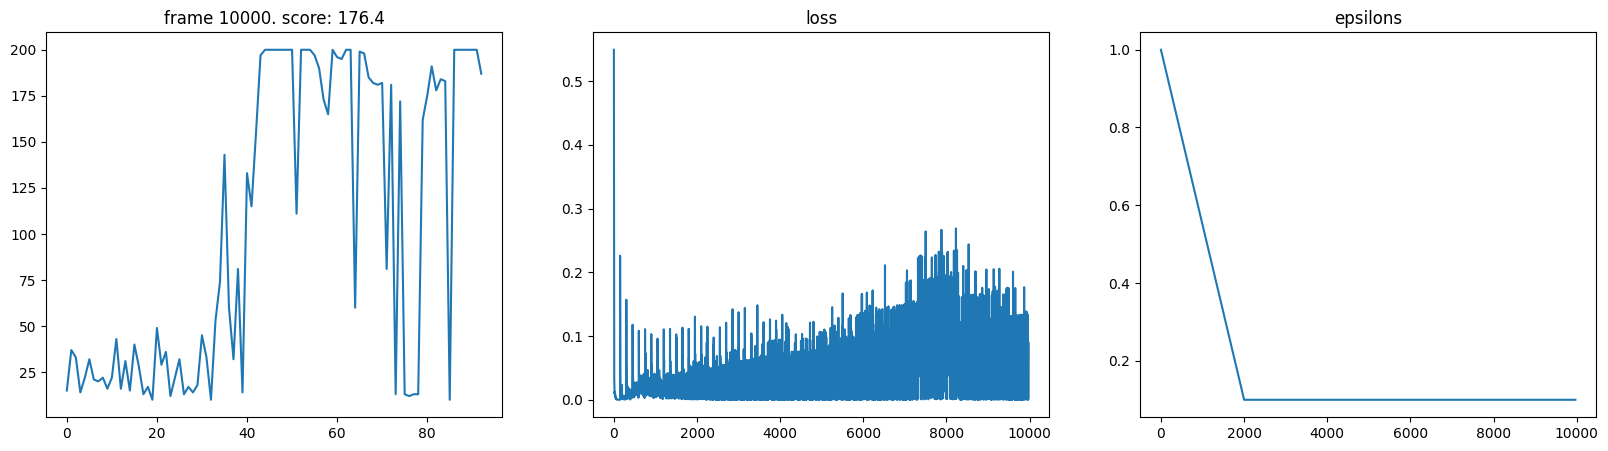

In [15]:
agent.train(num_frames)

## Test

Run the trained agent (1 episode).

In [16]:
video_folder="videos/per"
agent.test(video_folder=video_folder)

/opt/homebrew/Caskroom/miniconda/base/envs/pytorch_env/lib/python3.8/site-packages/gymnasium/core.py:297: UserWarning: WARN: env.is_vector_env to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.is_vector_env` for environment variables or `env.get_attr('is_vector_env')` that will search the reminding wrappers.
  logger.warn(


Moviepy - Building video /Users/vishalsankarram/Desktop/github/rainbow-is-all-you-need/videos/per/rl-video-episode-0.mp4.
Moviepy - Writing video /Users/vishalsankarram/Desktop/github/rainbow-is-all-you-need/videos/per/rl-video-episode-0.mp4



Moviepy - Done !
Moviepy - video ready /Users/vishalsankarram/Desktop/github/rainbow-is-all-you-need/videos/per/rl-video-episode-0.mp4
score:  167.0


## Render

In [17]:
import base64
import glob
import io
import os

from IPython.display import HTML, display


def ipython_show_video(path: str) -> None:
    """Show a video at `path` within IPython Notebook."""
    if not os.path.isfile(path):
        raise NameError("Cannot access: {}".format(path))

    video = io.open(path, "r+b").read()
    encoded = base64.b64encode(video)

    display(HTML(
        data="""
        <video width="320" height="240" alt="test" controls>
        <source src="data:video/mp4;base64,{0}" type="video/mp4"/>
        </video>
        """.format(encoded.decode("ascii"))
    ))


def show_latest_video(video_folder: str) -> str:
    """Show the most recently recorded video from video folder."""
    list_of_files = glob.glob(os.path.join(video_folder, "*.mp4"))
    latest_file = max(list_of_files, key=os.path.getctime)
    ipython_show_video(latest_file)
    return latest_file


latest_file = show_latest_video(video_folder=video_folder)
print("Played:", latest_file)

Played: videos/per/rl-video-episode-0.mp4
